# استخراج ماتریس نویز خوانش از داده IQ

مدل طبقه‌بندی: **Linear Discriminant Analysis (LDA)** روی صفحه IQ.

همه توابع در `src/readout_extraction/` هستند؛ این notebook فقط فراخوانی می‌کند.


## ساختار داده

```
quadrature_data_4qubits/
    1_1_2025/          # snapshot
    2_2_2025/
noise_matrix_results/
    res_1_1_2025/      # خروجی متناظر
    res_2_2_2025/
```

**ابتدا سلول Setup را اجرا کنید.**


In [1]:
# --- Setup: imports + config + load data ---
import numpy as np

from src.readout_extraction import (
    ReadoutDatasetConfig,
    load_all_data,
    train_all_classifiers,
    predict_full_dataset,
    build_noise_matrix,
    validate_noise_matrix,
    save_noise_matrix,
    run_noise_extraction,
    build_independent_noise_matrix,
    compare_noise_models,
    plot_fourqubit_state_overlay,
    plot_qubit_iq_clouds,
    plot_noise_matrix,
    plot_matrix_difference,
    run_readout_pipeline,
)

CAMPAIGN = "./quadrature_data_4qubits"
SNAPSHOT = "1_1_2025"

config = ReadoutDatasetConfig.from_snapshot(CAMPAIGN, SNAPSHOT)
config.classifier_type = "LDA"
config.qda_reg_param = 0.3

X, y, shots_per_file = load_all_data(config)
print(f"Loaded {X.shape[0]} shots from {config.data_dir}")
print(f"Results -> {config.output_dir}")


Loading 0000.txt
Loading 0001.txt
Loading 0010.txt
Loading 0011.txt
Loading 0100.txt
Loading 0101.txt
Loading 0110.txt
Loading 0111.txt
Loading 1000.txt
Loading 1001.txt
Loading 1010.txt
Loading 1011.txt
Loading 1100.txt
Loading 1101.txt
Loading 1110.txt
Loading 1111.txt

Final dataset shape:
X: (16000, 4)
y: (16000, 4)
Loaded 16000 shots from d:\SharifUniversity\N_Qubits_BinaryClassification\QNoisy_replicate\ReadouMatrixIqData\quadrature_data_4qubits\1_1_2025
Results -> d:\SharifUniversity\N_Qubits_BinaryClassification\QNoisy_replicate\ReadouMatrixIqData\noise_matrix_results\res_1_1_2025


### اجرای کامل خط لوله (اختیاری)


In [2]:
# همه مراحل: train -> matrix -> validate -> save -> plots -> comparison
results = run_readout_pipeline(config)
noise_matrix = results["noise_matrix"]
assignment_matrices = results["assignment_matrices"]


Campaign : quadrature_data_4qubits
Snapshot : 1_1_2025
Result   : res_1_1_2025
Input    : d:\SharifUniversity\N_Qubits_BinaryClassification\QNoisy_replicate\ReadouMatrixIqData\quadrature_data_4qubits\1_1_2025
Output   : d:\SharifUniversity\N_Qubits_BinaryClassification\QNoisy_replicate\ReadouMatrixIqData\noise_matrix_results\res_1_1_2025
Qubits   : 4
Classifier: LDA
Loading 0000.txt
Loading 0001.txt
Loading 0010.txt
Loading 0011.txt
Loading 0100.txt
Loading 0101.txt
Loading 0110.txt
Loading 0111.txt
Loading 1000.txt
Loading 1001.txt
Loading 1010.txt
Loading 1011.txt
Loading 1100.txt
Loading 1101.txt
Loading 1110.txt
Loading 1111.txt

Final dataset shape:
X: (16000, 4)
y: (16000, 4)
QUBIT 1
Test Accuracy = 0.712812
Single-Qubit Assignment Matrix:
[[0.794375 0.205625]
 [0.36875  0.63125 ]]
QUBIT 2
Test Accuracy = 0.819375
Single-Qubit Assignment Matrix:
[[0.874375 0.125625]
 [0.235625 0.764375]]
QUBIT 3
Test Accuracy = 0.804375
Single-Qubit Assignment Matrix:
[[0.885   0.115  ]
 [0.27625

### بررسی نمونه داده


In [3]:
X[0], y[0]


(array([ 11.+36.j, -56.+36.j,  16.+39.j,  14.+19.j]), array([0, 0, 0, 0]))

### نمودار overlay ابرهای IQ


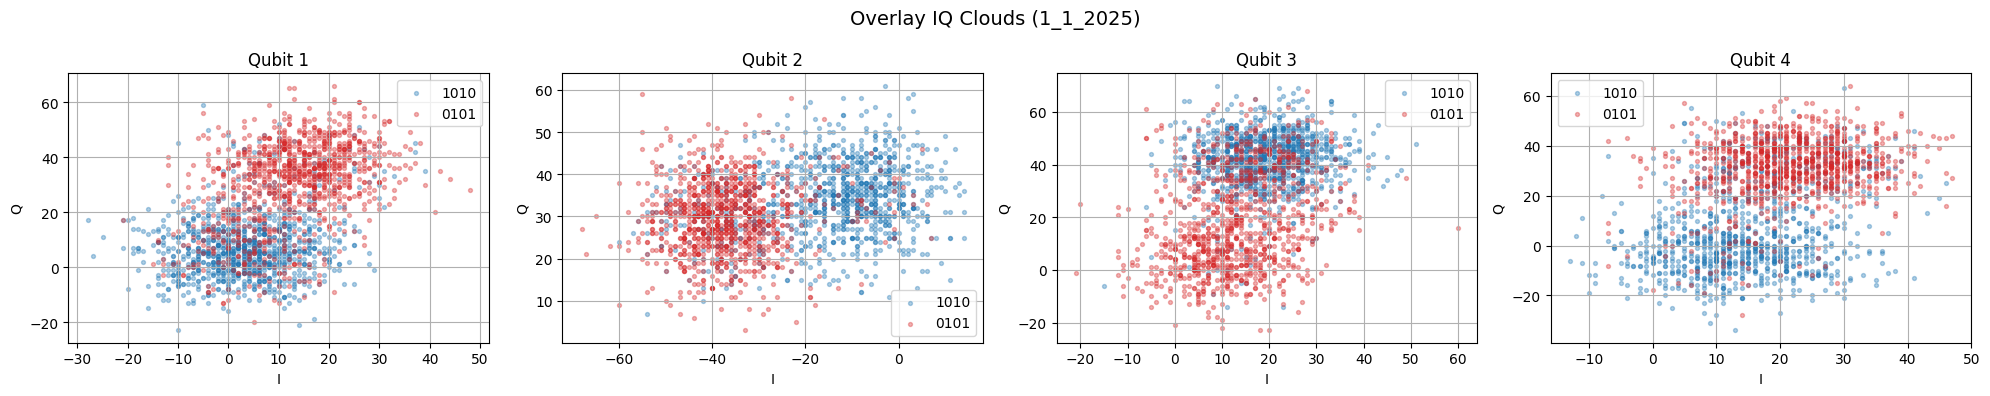

In [4]:
plot_fourqubit_state_overlay(
    X, y, config,
    target_states=("1010", "0101"),
    show=True,
)


### آموزش classifier تک‌کیوبیتی


In [5]:
classifiers, scalers, assignment_matrices = train_all_classifiers(X, y, config)
y_pred = predict_full_dataset(X, classifiers, scalers, config.num_qubits)


QUBIT 1
Test Accuracy = 0.712812
Single-Qubit Assignment Matrix:
[[0.794375 0.205625]
 [0.36875  0.63125 ]]
QUBIT 2
Test Accuracy = 0.819375
Single-Qubit Assignment Matrix:
[[0.874375 0.125625]
 [0.235625 0.764375]]
QUBIT 3
Test Accuracy = 0.804375
Single-Qubit Assignment Matrix:
[[0.885   0.115  ]
 [0.27625 0.72375]]
QUBIT 4
Test Accuracy = 0.820312
Single-Qubit Assignment Matrix:
[[0.891875 0.108125]
 [0.25125  0.74875 ]]


### ساخت ماتریس نویز 16×16


In [6]:
noise_matrix = build_noise_matrix(y, y_pred, config.num_qubits)
fidelity = noise_matrix.diagonal().mean()
print(f"Average assignment fidelity = {fidelity:.6f}")


Average assignment fidelity = 0.384875


### اعتبارسنجی و ذخیره


In [7]:
validate_noise_matrix(noise_matrix)
save_noise_matrix(noise_matrix, config.output_dir, config.num_qubits)


VALIDATION
Row sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Diagonal elements:
[0.626 0.414 0.489 0.379 0.411 0.439 0.387 0.275 0.508 0.328 0.42  0.305
 0.377 0.218 0.334 0.248]
Average diagonal fidelity:
0.38487499999999997


### heatmap ماتریس نویز


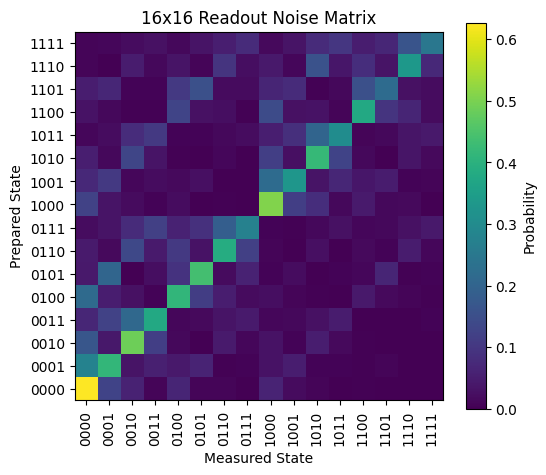

In [8]:
plot_noise_matrix(
    noise_matrix,
    config,
    show=True,
)


### مقایسه LDA و QDA


In [9]:
M_LDA = run_noise_extraction(X, y, config, classifier_type="LDA")
M_QDA = run_noise_extraction(X, y, config, classifier_type="QDA", qda_reg_param=0.30)

print("Mean diag LDA:", M_LDA.diagonal().mean())
print("Mean diag QDA:", M_QDA.diagonal().mean())
print("Frobenius norm:", np.linalg.norm(M_LDA - M_QDA))
print("Max abs diff:", np.max(np.abs(M_LDA - M_QDA)))


QUBIT 1
Test Accuracy = 0.712812
Single-Qubit Assignment Matrix:
[[0.794375 0.205625]
 [0.36875  0.63125 ]]
QUBIT 2
Test Accuracy = 0.819375
Single-Qubit Assignment Matrix:
[[0.874375 0.125625]
 [0.235625 0.764375]]
QUBIT 3
Test Accuracy = 0.804375
Single-Qubit Assignment Matrix:
[[0.885   0.115  ]
 [0.27625 0.72375]]
QUBIT 4
Test Accuracy = 0.820312
Single-Qubit Assignment Matrix:
[[0.891875 0.108125]
 [0.25125  0.74875 ]]
VALIDATION
Row sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Diagonal elements:
[0.626 0.414 0.489 0.379 0.411 0.439 0.387 0.275 0.508 0.328 0.42  0.305
 0.377 0.218 0.334 0.248]
Average diagonal fidelity:
0.38487499999999997
QUBIT 1
Test Accuracy = 0.710313
Single-Qubit Assignment Matrix:
[[0.838125 0.161875]
 [0.4175   0.5825  ]]
QUBIT 2
Test Accuracy = 0.822187
Single-Qubit Assignment Matrix:
[[0.886875 0.113125]
 [0.2425   0.7575  ]]
QUBIT 3
Test Accuracy = 0.801875
Single-Qubit Assignment Matrix:
[[0.898125 0.101875]
 [0.294375 0.705625]]
QUBIT 4
Test

### ابر IQ تک‌کیوبیتی (مثال کیوبیت 1)


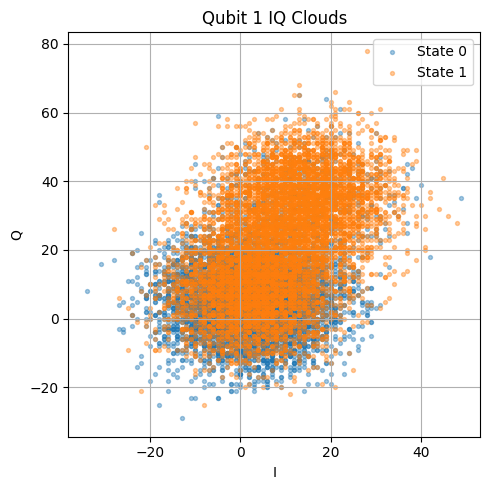

In [12]:
plot_qubit_iq_clouds(X, y, qubit_index=0, show=True)


### مقایسه مدل همبسته و مستقل (Kronecker)



COMPARISON RESULTS

Frobenius norm : 0.267485
Max abs diff   : 0.117124
Mean abs diff  : 0.008659

Diagonal fidelities (REAL):
[0.626 0.414 0.489 0.379 0.411 0.439 0.387 0.275 0.508 0.328 0.42  0.305
 0.377 0.218 0.334 0.248]

Diagonal fidelities (INDEPENDENT):
[0.5482 0.4357 0.4793 0.3809 0.4483 0.3563 0.3919 0.3115 0.4603 0.3657
 0.4024 0.3197 0.3764 0.2991 0.329  0.2615]


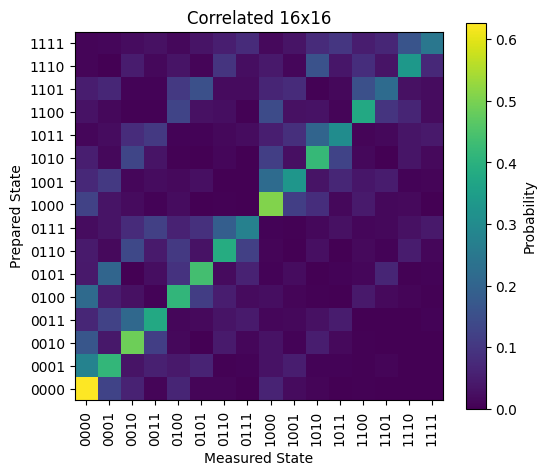

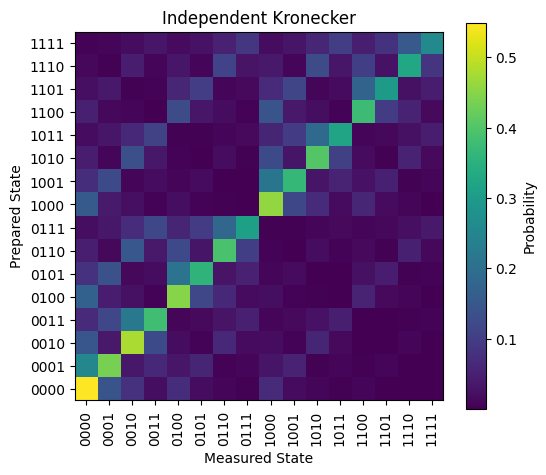

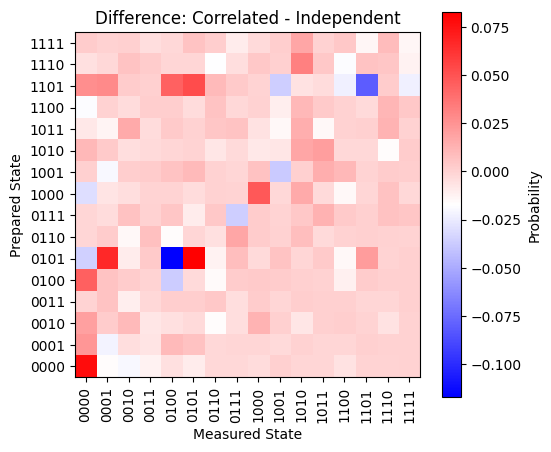

Row sums (real): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Row sums (indep): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
A_real = noise_matrix
A_indep = build_independent_noise_matrix(assignment_matrices)
compare_noise_models(A_real, A_indep)

plot_noise_matrix(A_real, config, title="Correlated 16x16", show=True)
plot_noise_matrix(A_indep, config, title="Independent Kronecker", show=True)
plot_matrix_difference(
    A_real - A_indep,
    config,
    title="Difference: Correlated - Independent",
    show=True,
)

print("Row sums (real):", np.round(A_real.sum(axis=1), 6))
print("Row sums (indep):", np.round(A_indep.sum(axis=1), 6))
